<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/ML_Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Diabetes Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##Load the Dataset


In [2]:
data = pd.read_csv('/content/diabetes-kaggle-dataset.csv')  #connecting to data set
df = pd.DataFrame(data)    #converting the data to dataframe
df.head()  #checking the connectivit

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Perform Basic Preprocessing

In [8]:
#checking for missing values
missing = (df.isnull().sum())

print(missing)
if (missing.any() == False):
  print("No missing values found")

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
No missing values found


In [12]:
#Prepare features (X) and target variable (y)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#splitting the data

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


##Train Models


In [15]:
#Support Vector Machine (SVM)

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
svm_results = {}

for kernel in kernels:
    # Train SVM Model
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)

    # Store metrics
    svm_results[kernel] = {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'cm': confusion_matrix(y_test, y_pred_svm),
        'report': classification_report(y_test, y_pred_svm)
    }
    print(f" - SVM [{kernel} Kernel] Accuracy: {svm_results[kernel]['accuracy']:.4f}")

 - SVM [linear Kernel] Accuracy: 0.7597
 - SVM [rbf Kernel] Accuracy: 0.7273
 - SVM [sigmoid Kernel] Accuracy: 0.6558
 - SVM [poly Kernel] Accuracy: 0.7468


Optimal K determined via Elbow: K = 18



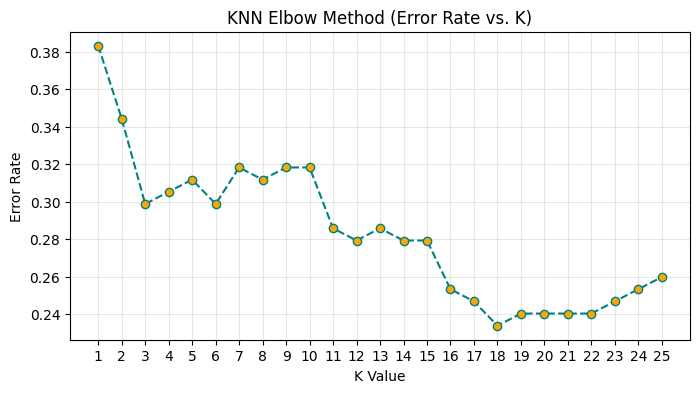

In [17]:
#K-Nearest Neighbors (KNN)

error_rates = []
k_range = range(1, 26)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    error_rates.append(np.mean(y_pred_k != y_test))

# Determine optimal K (index of minimum error rate)
optimal_k = k_range[np.argmin(error_rates)]
print(f"Optimal K determined via Elbow: K = {optimal_k}\n")

# Plotting the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, error_rates, color='teal', linestyle='dashed', marker='o', markerfacecolor='orange', markersize=6)
plt.title('KNN Elbow Method (Error Rate vs. K)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

## Model Evaluation  and comparison

In [21]:
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_cm = confusion_matrix(y_test, y_pred_knn)
knn_report = classification_report(y_test, y_pred_knn)

best_svm_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])

print("\n")
print(f"  DETAILED EVALUATION: SVM ({best_svm_kernel.upper()} KERNEL)")
print("="*50)
print(f"Accuracy Score: {svm_results[best_svm_kernel]['accuracy']:.4f}\n")
print("Confusion Matrix:")
print(svm_results[best_svm_kernel]['cm'])
print("\nClassification Report:")
print(svm_results[best_svm_kernel]['report'])

print("\n")
print(f"  DETAILED EVALUATION: KNN (K = {optimal_k})")
print("="*50)
print(f"Accuracy Score: {knn_accuracy:.4f}\n")
print("Confusion Matrix:")
print(knn_cm)
print("\nClassification Report:")
print(knn_report)



  DETAILED EVALUATION: SVM (LINEAR KERNEL)
Accuracy Score: 0.7597

Confusion Matrix:
[[81 18]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



  DETAILED EVALUATION: KNN (K = 18)
Accuracy Score: 0.7662

Confusion Matrix:
[[89 10]
 [26 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        99
           1       0.74      0.53      0.62        55

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154

